<a href="https://colab.research.google.com/github/alisony755/DS4400/blob/main/HW4/DS3000_HW4_Problem2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem 2

In [3]:
# Import required libraries
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt

In [4]:
# Get spambase data
!pip install -U ucimlrepo

from ucimlrepo import fetch_ucirepo

# Fetch dataset
spambase = fetch_ucirepo(id=94)

# Data (as pandas dataframes)
X = spambase.data.features
y = spambase.data.targets

# Print metadata
print(spambase.metadata)

# Print variable information
print(spambase.variables)

{'uci_id': 94, 'name': 'Spambase', 'repository_url': 'https://archive.ics.uci.edu/dataset/94/spambase', 'data_url': 'https://archive.ics.uci.edu/static/public/94/data.csv', 'abstract': 'Classifying Email as Spam or Non-Spam', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 4601, 'num_features': 57, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1999, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C53G6X', 'creators': ['Mark Hopkins', 'Erik Reeber', 'George Forman', 'Jaap Suermondt'], 'intro_paper': None, 'additional_info': {'summary': 'The "spam" concept is diverse: advertisements for products/web sites, make money fast schemes, chain letters, pornography...\n\nThe classification task for this dataset is to determine whether a given email is spam or not.\n\t\nOur collecti

In [5]:
# Convert dataset to numpy arrays
X = X.values
y = y.values.ravel()  # flatten target array

# Split dataset into training (75%) and testing (25%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

In [6]:
def compute_metrics(y_true, y_pred, y_probs, dataset_name="Dataset"):
  """ Computes and prints classification metrics.

  Args:
    y_true (numpy.ndarray): True labels
    y_pred (numpy.ndarray): Predicted class labels
    y_probs (numpy.ndarray): Predicted probabilities for positive class
    dataset_name (str): Name of dataset (e.g., "Training", "Testing")

  Returns:
    tuple: (accuracy, f1, auc)
  """

  # Compute accuracy
  accuracy = accuracy_score(y_true, y_pred)

  # Compute F1 score
  f1 = f1_score(y_true, y_pred)

  # Compute AUC score
  auc = roc_auc_score(y_true, y_probs)

  # Print labeled results
  print(f"\n{dataset_name} Metrics")
  print(f"Accuracy: {accuracy:.4f}")
  print(f"F1 Score: {f1:.4f}")
  print(f"AUC: {auc:.4f}")

  return accuracy, f1, auc

### 2.1

In [7]:
# Different numbers of trees to evaluate
tree_counts = [10, 50, 100, 500]

# Loop over each value of T (number of trees)
for T in tree_counts:

    print(f"\nRandom Forest with {T} Trees:")

    # Create Random Forest model
    rf = RandomForestClassifier(
        n_estimators=T,      # Number of trees
        random_state=42,
        n_jobs=-1            # Use all processors (faster)
    )

    # Train model on training data
    rf.fit(X_train, y_train)

    # Predict class labels
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)

    # Predict probabilities for AUC
    y_train_probs = rf.predict_proba(X_train)[:, 1]
    y_test_probs = rf.predict_proba(X_test)[:, 1]

    # Compute and print metrics
    compute_metrics(y_train, y_train_pred, y_train_probs, "Training")
    compute_metrics(y_test, y_test_pred, y_test_probs, "Testing")


Random Forest with 10 Trees:

Training Metrics
Accuracy: 0.9957
F1 Score: 0.9944
AUC: 0.9999

Testing Metrics
Accuracy: 0.9461
F1 Score: 0.9329
AUC: 0.9818

Random Forest with 50 Trees:

Training Metrics
Accuracy: 0.9994
F1 Score: 0.9993
AUC: 1.0000

Testing Metrics
Accuracy: 0.9583
F1 Score: 0.9482
AUC: 0.9884

Random Forest with 100 Trees:

Training Metrics
Accuracy: 0.9994
F1 Score: 0.9993
AUC: 1.0000

Testing Metrics
Accuracy: 0.9583
F1 Score: 0.9482
AUC: 0.9879

Random Forest with 500 Trees:

Training Metrics
Accuracy: 0.9994
F1 Score: 0.9993
AUC: 1.0000

Testing Metrics
Accuracy: 0.9583
F1 Score: 0.9483
AUC: 0.9876


### 2.3

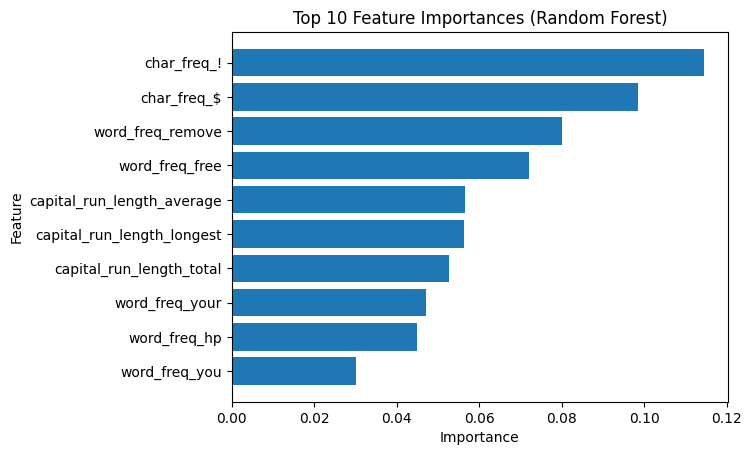

In [8]:
# Train model
rf_final = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

# Get feature importance scores
importances = rf_final.feature_importances_

# Convert to DataFrame
feature_names = spambase.data.features.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort features by importance (descending)
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Plot top 10 most important features
plt.figure()

plt.barh(
    importance_df["Feature"][:10],
    importance_df["Importance"][:10]
)

# Invert y-axis so most important feature is on top
plt.gca().invert_yaxis()

# Label axes
plt.xlabel("Importance")
plt.ylabel("Feature")

# Title
plt.title("Top 10 Feature Importances (Random Forest)")

# Show plot
plt.show()